In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from pathlib import Path
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

sys.path.append(str(Path().resolve().parent))
from config import OUTPUT_DIR, SILVER_DATASET

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.2)
plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.spines.top": False,
    "axes.spines.right": False, "axes.titlesize": 14,
    "axes.titleweight": "bold", "axes.labelsize": 12,
})

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Configurações aplicadas ✅")

Configurações aplicadas ✅


In [10]:
df = pd.read_csv(SILVER_DATASET)
print(f"Registros: {len(df):,} | Colunas: {df.shape[1]}")
print(f"Taxa de default: {df['default_12m'].mean()*100:.1f}%")
print()
print(df['default_12m'].value_counts().rename({0:'Adimplente', 1:'Inadimplente'}))

Registros: 24,974 | Colunas: 37
Taxa de default: 16.6%

default_12m
Adimplente      20822
Inadimplente     4152
Name: count, dtype: int64


In [11]:
FEATURES_CAT = [
    'customer_segment', 'industry_sector', 'collateral_type',
    'regiao', 'compliance_status', 'env_risk_level',
    'doc_type', 'normalization_method'
]
FEATURES_NUM = [
    'credit_requested_value', 'income_declared', 'tenure_months', 'ltv',
    'ocr_confidence', 'match_score', 'data_quality_score', 'rule_violations',
    'drought_spi', 'flood_risk_idx', 'ndvi', 'fire_hotspots_30d',
    'deforestation_km2_12m', 'normalized_amount', 'pii_detected', 'is_duplicate'
]
FEATURES = FEATURES_CAT + FEATURES_NUM
TARGET   = 'default_12m'

X = df[FEATURES].copy()
y = df[TARGET]

print(f"Features categóricas : {len(FEATURES_CAT)}")
print(f"Features numéricas   : {len(FEATURES_NUM)}")
print(f"Total de features    : {len(FEATURES)}")

Features categóricas : 8
Features numéricas   : 16
Total de features    : 24


In [12]:
# Encoding das categóricas
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[FEATURES_CAT] = enc.fit_transform(X[FEATURES_CAT])

# Split estratificado — mantém proporção de default em treino e teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino : {len(X_train):,} ({len(X_train)/len(X)*100:.0f}%)")
print(f"Teste  : {len(X_test):,}  ({len(X_test)/len(X)*100:.0f}%)")
print(f"Default no treino: {y_train.mean()*100:.1f}%")
print(f"Default no teste : {y_test.mean()*100:.1f}%")

Treino : 19,979 (80%)
Teste  : 4,995  (20%)
Default no treino: 16.6%
Default no teste : 16.6%


In [13]:
rf = RandomForestClassifier(
    n_estimators=200,       # 200 árvores
    max_depth=10,           # profundidade máxima — evita overfitting
    min_samples_leaf=20,    # mínimo de amostras por folha
    class_weight='balanced',# compensa o desbalanceamento (83% vs 17%)
    random_state=42,
    n_jobs=-1               # usa todos os núcleos disponíveis
)

rf.fit(X_train, y_train)
print("Modelo treinado ✅")
print(f"Árvores: {rf.n_estimators} | Profundidade máx: {rf.max_depth}")

Modelo treinado ✅
Árvores: 200 | Profundidade máx: 10


In [14]:
y_pred  = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]
auc     = roc_auc_score(y_test, y_proba)

print(f"AUC-ROC : {auc:.4f}")
print()
print(classification_report(y_test, y_pred,
                             target_names=['Adimplente','Inadimplente']))

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')
print(f"Cross-val AUC (5-fold): {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

AUC-ROC : 0.5757

              precision    recall  f1-score   support

  Adimplente       0.85      0.84      0.84      4165
Inadimplente       0.23      0.25      0.24       830

    accuracy                           0.74      4995
   macro avg       0.54      0.54      0.54      4995
weighted avg       0.75      0.74      0.74      4995

Cross-val AUC (5-fold): 0.5596 ± 0.0124


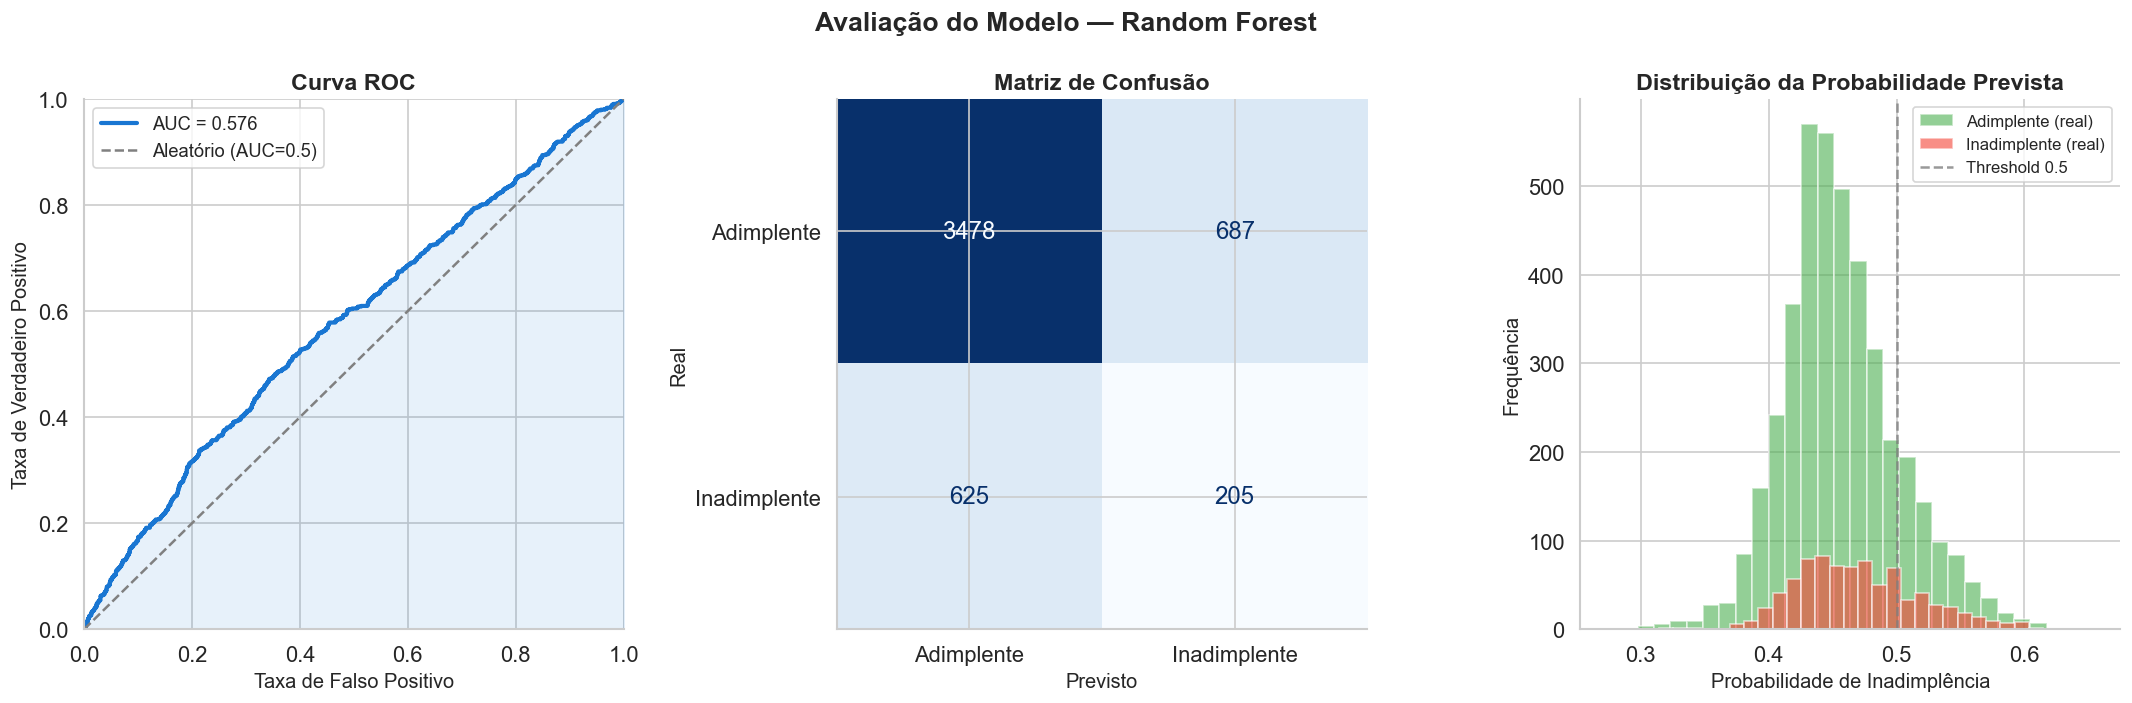

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Avaliação do Modelo — Random Forest",
             fontsize=16, fontweight="bold")

# ── Curva ROC ────────────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[0].plot(fpr, tpr, color="#1976d2", lw=2.5,
             label=f"AUC = {auc:.3f}")
axes[0].plot([0,1],[0,1], color="gray", lw=1.5,
             linestyle="--", label="Aleatório (AUC=0.5)")
axes[0].fill_between(fpr, tpr, alpha=0.1, color="#1976d2")
axes[0].set_title("Curva ROC")
axes[0].set_xlabel("Taxa de Falso Positivo")
axes[0].set_ylabel("Taxa de Verdadeiro Positivo")
axes[0].legend(fontsize=11)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)

# ── Matriz de confusão ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Adimplente", "Inadimplente"]
)
disp.plot(ax=axes[1], colorbar=False, cmap="Blues")
axes[1].set_title("Matriz de Confusão")
axes[1].set_xlabel("Previsto")
axes[1].set_ylabel("Real")

# ── Distribuição de probabilidade prevista ───────────────────────────────────
prob_df = pd.DataFrame({"prob": y_proba, "real": y_test.values})
axes[2].hist(prob_df[prob_df["real"]==0]["prob"], bins=30, alpha=0.6,
             color="#4caf50", label="Adimplente (real)")
axes[2].hist(prob_df[prob_df["real"]==1]["prob"], bins=30, alpha=0.6,
             color="#f44336", label="Inadimplente (real)")
axes[2].axvline(x=0.5, color="gray", linestyle="--", alpha=0.8,
                label="Threshold 0.5")
axes[2].set_title("Distribuição da Probabilidade Prevista")
axes[2].set_xlabel("Probabilidade de Inadimplência")
axes[2].set_ylabel("Frequência")
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/modelo_01_avaliacao.png", bbox_inches="tight")
plt.show()

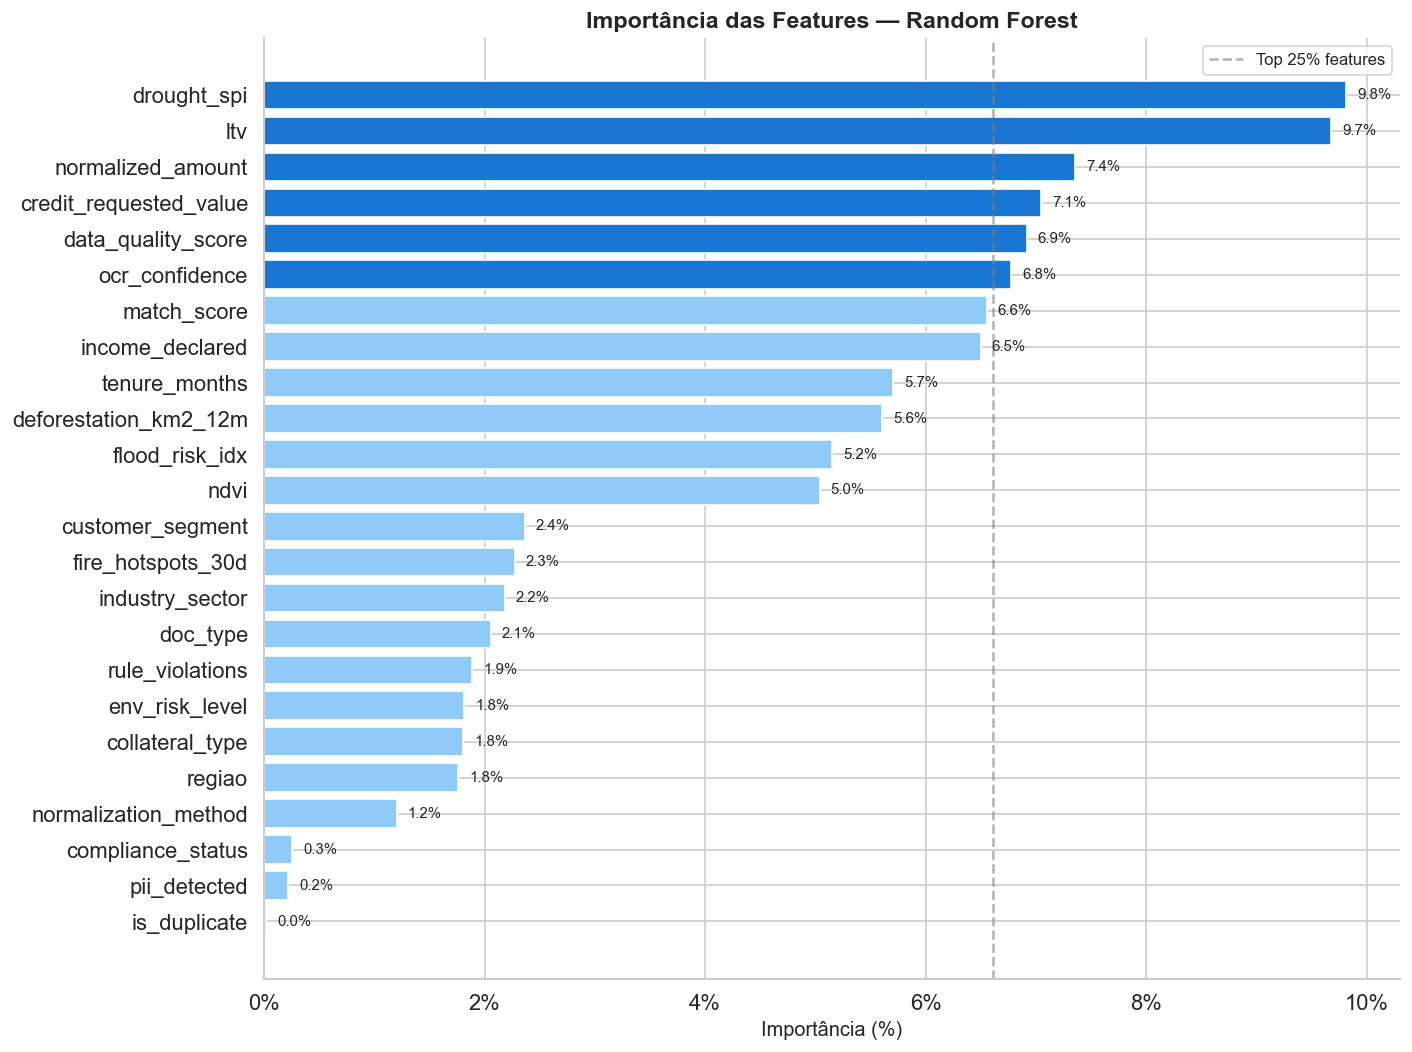

Top 5 features mais importantes:
drought_spi               9.81%
ltv                       9.68%
normalized_amount         7.35%
credit_requested_value    7.05%
data_quality_score        6.92%
dtype: str


In [18]:
importances = (
    pd.Series(rf.feature_importances_, index=FEATURES)
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(12, 9))
cores = ["#1976d2" if v >= importances.quantile(0.75) else "#90caf9"
         for v in importances]
bars = ax.barh(importances.index, importances.values,
               color=cores, edgecolor="white", linewidth=1)
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val*100:.1f}%", va="center", fontsize=9)

ax.set_title("Importância das Features — Random Forest")
ax.set_xlabel("Importância (%)")
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x*100:.0f}%")
)
ax.axvline(x=importances.quantile(0.75), color="gray",
           linestyle="--", alpha=0.6, label="Top 25% features")
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/modelo_02_importancia.png", bbox_inches="tight")
plt.show()

print("Top 5 features mais importantes:")
print(importances.tail(5).sort_values(ascending=False)
      .mul(100).round(2).astype(str).add("%"))

Perfil médio — Adimplente vs Inadimplente:
default_12m             ✅ Adimplente  ❌ Inadimplente  Diferença (%)
ltv                             0.56            0.65           16.1
drought_spi                    -0.17           -0.32          -88.2
normalized_amount           15931.93        16926.33            6.2
credit_requested_value      17511.13        18671.40            6.6
income_declared             37836.75        38394.40            1.5
data_quality_score              0.72            0.71           -1.4
match_score                     0.67            0.66           -1.5
ocr_confidence                  0.70            0.69           -1.4
tenure_months                 119.42          120.16            0.6


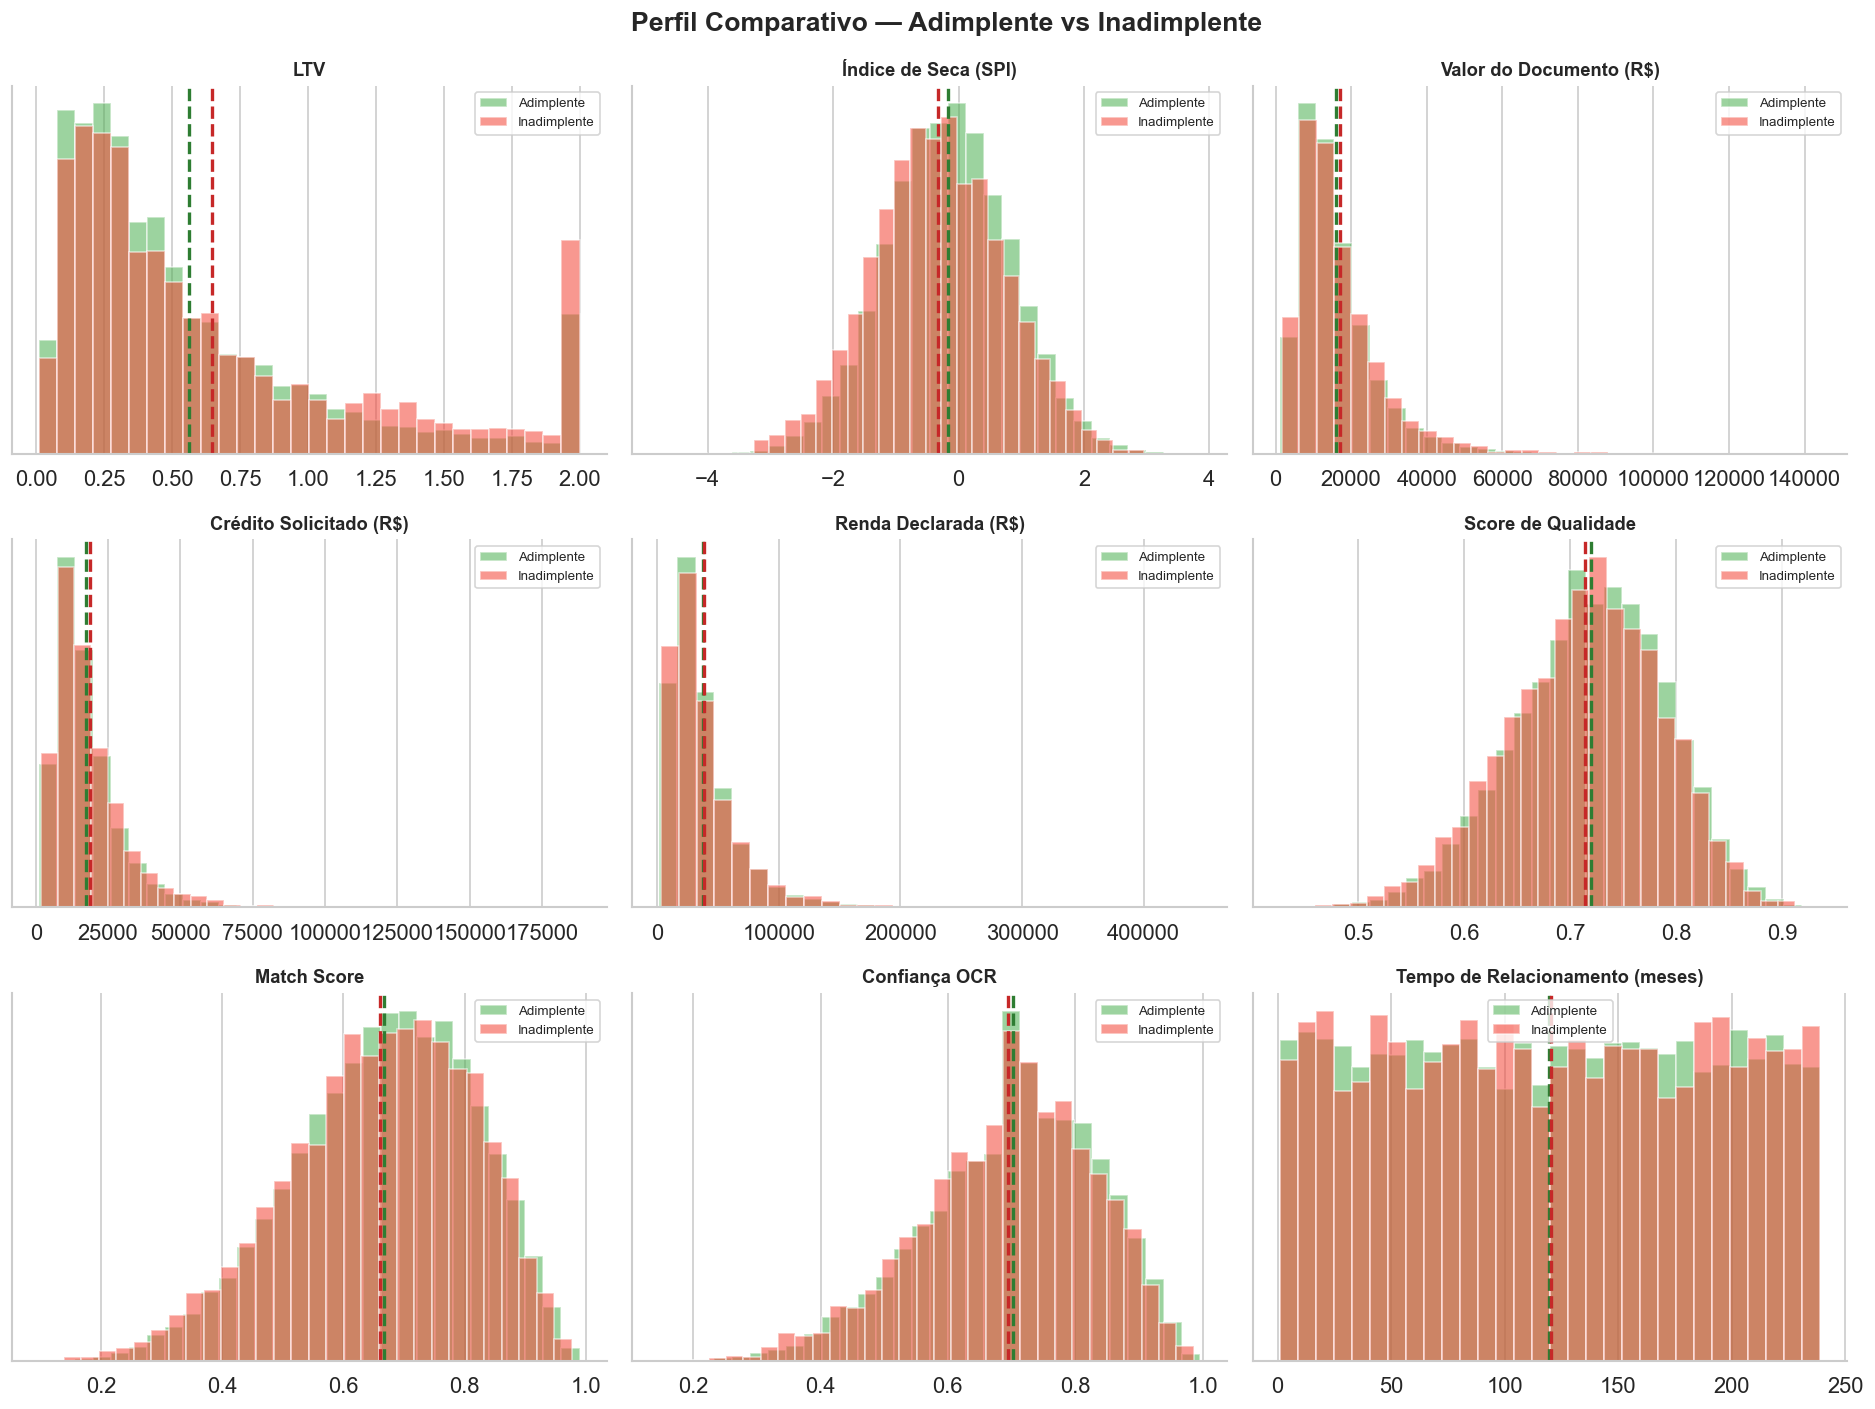

In [20]:
top_features_num = [
    'ltv', 'drought_spi', 'normalized_amount', 'credit_requested_value',
    'income_declared', 'data_quality_score', 'match_score', 'ocr_confidence',
    'tenure_months'
]

perfil = (
    df.groupby('default_12m')[top_features_num]
    .mean()
    .round(2)
    .rename(index={0: '✅ Adimplente', 1: '❌ Inadimplente'})
    .T
)
perfil['Diferença (%)'] = (
    (perfil['❌ Inadimplente'] - perfil['✅ Adimplente'])
    / perfil['✅ Adimplente'].abs() * 100
).round(1)

print("Perfil médio — Adimplente vs Inadimplente:")
print(perfil.to_string())

# Gráfico de perfil
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle("Perfil Comparativo — Adimplente vs Inadimplente",
             fontsize=16, fontweight="bold")
axes = axes.flatten()

labels_feat = {
    'ltv'                  : 'LTV',
    'drought_spi'          : 'Índice de Seca (SPI)',
    'normalized_amount'    : 'Valor do Documento (R$)',
    'credit_requested_value': 'Crédito Solicitado (R$)',
    'income_declared'      : 'Renda Declarada (R$)',
    'data_quality_score'   : 'Score de Qualidade',
    'match_score'          : 'Match Score',
    'ocr_confidence'       : 'Confiança OCR',
    'tenure_months'        : 'Tempo de Relacionamento (meses)',
}

for i, feat in enumerate(top_features_num):
    adim   = df[df['default_12m']==0][feat]
    inadim = df[df['default_12m']==1][feat]

    axes[i].hist(adim,   bins=30, alpha=0.55, color='#4caf50',
                 label='Adimplente',   density=True)
    axes[i].hist(inadim, bins=30, alpha=0.55, color='#f44336',
                 label='Inadimplente', density=True)
    axes[i].axvline(adim.mean(),   color='#2e7d32', lw=2, linestyle='--')
    axes[i].axvline(inadim.mean(), color='#c62828', lw=2, linestyle='--')
    axes[i].set_title(labels_feat[feat], fontsize=11)
    axes[i].legend(fontsize=8)
    axes[i].set_yticks([])

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/modelo_03_perfil.png", bbox_inches="tight")
plt.show()

In [26]:
joblib.dump(rf,  f"{OUTPUT_DIR}/modelo_rf.joblib")
joblib.dump(enc, f"{OUTPUT_DIR}/encoder_cat.joblib")

# Salvar metadados do modelo
meta = {
    "algoritmo"        : "RandomForestClassifier",
    "n_estimators"     : rf.n_estimators,
    "max_depth"        : rf.max_depth,
    "class_weight"     : "balanced",
    "auc_roc_teste"    : round(auc, 4),
    "auc_crossval_mean": round(cv_auc.mean(), 4),
    "auc_crossval_std" : round(cv_auc.std(), 4),
    "features_cat"     : FEATURES_CAT,
    "features_num"     : FEATURES_NUM,
    "target"           : TARGET,
    "train_size"       : len(X_train),
    "test_size"        : len(X_test),
}
import json
with open(f"{OUTPUT_DIR}/modelo_metadata.json", "w") as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)

print("✅ modelo_rf.joblib salvo")
print("✅ encoder_cat.joblib salvo")
print("✅ modelo_metadata.json salvo")
print(f"\nAUC-ROC final: {auc:.4f}")

✅ modelo_rf.joblib salvo
✅ encoder_cat.joblib salvo
✅ modelo_metadata.json salvo

AUC-ROC final: 0.5757


In [27]:
# Exemplo: preencher com o perfil de um novo cliente
novo_cliente = pd.DataFrame([{
    # Categóricas
    'customer_segment'  : 'PF',
    'industry_sector'   : 'SERVICOS',
    'collateral_type'   : 'IMOVEL',
    'regiao'            : 'SE',
    'compliance_status' : 'OK',
    'env_risk_level'    : 'BAIXO',
    'doc_type'          : 'EXTRATO',
    'normalization_method': 'RULES_V2',
    # Numéricas
    'credit_requested_value': 15000,
    'income_declared'       : 5000,
    'tenure_months'         : 24,
    'ltv'                   : 0.6,
    'ocr_confidence'        : 0.85,
    'match_score'           : 0.75,
    'data_quality_score'    : 0.80,
    'rule_violations'       : 0,
    'drought_spi'           : 0.1,
    'flood_risk_idx'        : 0.2,
    'ndvi'                  : 0.5,
    'fire_hotspots_30d'     : 1,
    'deforestation_km2_12m' : 0.5,
    'normalized_amount'     : 14800,
    'pii_detected'          : 0,
    'is_duplicate'          : 0,
}])

# Aplicar encoder
novo_enc = novo_cliente.copy()
novo_enc[FEATURES_CAT] = enc.transform(novo_enc[FEATURES_CAT])

# Previsão
prob_inadimplencia = rf.predict_proba(novo_enc[FEATURES])[0, 1]
decisao = "❌ ALTO RISCO" if prob_inadimplencia > 0.5 else "✅ BAIXO RISCO"

print("=" * 45)
print("PREVISÃO PARA O PERFIL INFORMADO")
print("=" * 45)
print(f"Probabilidade de inadimplência : {prob_inadimplencia*100:.1f}%")
print(f"Classificação                  : {decisao}")
print("=" * 45)

PREVISÃO PARA O PERFIL INFORMADO
Probabilidade de inadimplência : 40.3%
Classificação                  : ✅ BAIXO RISCO
